In [154]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize

import torch
import torch.nn as nn
import torch.optim as optim

In [155]:
data = pd.read_csv("../data/processed_data.csv", index_col=0, parse_dates=True)
data = data.sort_index()
data.head()

,EEM,GLD,IWM,LQD,QQQ,SPY,TLT,VNQ,EEM_vol20,GLD_vol20,...,QQQ_mom50,SPY_mom50,TLT_mom50,VNQ_mom50,market_price,market_return,ma50,ma200,drawdown,regime
Date,,,,,,,,,,,,,,,,,,,,,
2005-10-17,0.010974,0.009781,0.001746,0.001391,0.003148,0.003701,-0.000223,0.005779,0.015855,0.008897,...,-0.032928,-0.026554,-0.008490,-0.033373,43.271372,0.003855,43.879468,42.513939,-0.029782,bull
2005-10-18,-0.025708,-0.005517,-0.013580,0.001296,-0.007097,-0.010889,0.001108,-0.009650,0.016647,0.009014,...,-0.032661,-0.035291,-0.005547,-0.006862,42.948885,-0.007481,43.869834,42.518100,-0.037040,sideways
2005-10-19,0.019343,-0.014142,0.021325,0.001017,0.019848,0.016498,0.000443,0.011220,0.017195,0.008672,...,-0.019772,-0.025125,-0.008790,-0.000328,43.326986,0.008765,43.863999,42.526939,-0.028600,bull
2005-10-20,-0.041061,-0.007799,-0.018754,-0.002499,-0.009353,-0.017772,0.002653,-0.015992,0.019142,0.008187,...,-0.020455,-0.041832,-0.005073,-0.025589,42.816533,-0.011851,43.847160,42.534736,-0.040112,sideways
2005-10-21,0.026265,0.011676,0.011009,0.005268,0.006245,0.003901,0.009230,0.009521,0.020349,0.008611,...,-0.022318,-0.041893,-0.002805,-0.029189,43.184587,0.008559,43.831306,42.544252,-0.031896,bull


In [156]:
asset_cols = ["SPY", "QQQ", "TLT", "GLD", "EEM", "IWM", "VNQ", "LQD"]
vol_cols = [c for c in data.columns if "vol20" in c]
mom_cols = [c for c in data.columns if "mom50" in c]

print("assets:", asset_cols)
print("vol cols:", vol_cols)
print("mom cols:", mom_cols)

assets: ['SPY', 'QQQ', 'TLT', 'GLD', 'EEM', 'IWM', 'VNQ', 'LQD']
vol cols: ['EEM_vol20', 'GLD_vol20', 'IWM_vol20', 'LQD_vol20', 'QQQ_vol20', 'SPY_vol20', 'TLT_vol20', 'VNQ_vol20']
mom cols: ['EEM_mom50', 'GLD_mom50', 'IWM_mom50', 'LQD_mom50', 'QQQ_mom50', 'SPY_mom50', 'TLT_mom50', 'VNQ_mom50']


In [157]:
#returns and feature 
returns = data[asset_cols].copy()
volatility = data[vol_cols].copy()
momentum = data[mom_cols].copy()

regime_map = {"bear": 0,"sideways": 1,"bull": 2}

regime_encoded = data["regime"].map(regime_map)

x = pd.concat([returns, volatility, momentum], axis=1).copy()
x["regime"] = regime_encoded
x = x.dropna()
y = returns.loc[X.index].copy()

print("x shape:", x.shape)
print("y shape:", y.shape)

x.head()

x shape: (4833, 25)
y shape: (4833, 8)


,SPY,QQQ,TLT,GLD,EEM,IWM,VNQ,LQD,EEM_vol20,GLD_vol20,...,VNQ_vol20,EEM_mom50,GLD_mom50,IWM_mom50,LQD_mom50,QQQ_mom50,SPY_mom50,TLT_mom50,VNQ_mom50,regime
Date,,,,,,,,,,,,,,,,,,,,,
2005-10-17,0.003701,0.003148,-0.000223,0.009781,0.010974,0.001746,0.005779,0.001391,0.015855,0.008897,...,0.012478,0.018088,0.083945,-0.041795,-0.010063,-0.032928,-0.026554,-0.008490,-0.033373,2
2005-10-18,-0.010889,-0.007097,0.001108,-0.005517,-0.025708,-0.013580,-0.009650,0.001296,0.016647,0.009014,...,0.012528,-0.014500,0.084198,-0.051412,-0.004249,-0.032661,-0.035291,-0.005547,-0.006862,1
2005-10-19,0.016498,0.019848,0.000443,-0.014142,0.019343,0.021325,0.011220,0.001017,0.017195,0.008672,...,0.011967,-0.015095,0.069220,-0.032439,-0.004873,-0.019772,-0.025125,-0.008790,-0.000328,2
2005-10-20,-0.017772,-0.009353,0.002653,-0.007799,-0.041061,-0.018754,-0.015992,-0.002499,0.019142,0.008187,...,0.012333,-0.064716,0.053379,-0.049115,-0.008172,-0.020455,-0.041832,-0.005073,-0.025589,1
2005-10-21,0.003901,0.006245,0.009230,0.011676,0.026265,0.011009,0.009521,0.005268,0.020349,0.008611,...,0.012584,-0.034418,0.046569,-0.046852,-0.006014,-0.022318,-0.041893,-0.002805,-0.029189,2


In [158]:
train_end = "2017-12-31"

x_train = x.loc[:train_end].copy()
x_test = x.loc["2018-01-01":].copy()

y_train = y.loc[:train_end].copy()
y_test = y.loc["2018-01-01":].copy()

print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3073, 25)
X_test : (1760, 25)
y_train: (3073, 8)
y_test : (1760, 8)


In [159]:
#convert tensors 
x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [160]:
#metric 
def sharpe_ratio(r, annualization=252):
    r = pd.Series(r).dropna()
    if r.std() == 0:
        return 0.0
    return np.sqrt(annualization) * r.mean() / r.std()

def max_drawdown(r):
    r = pd.Series(r).dropna()
    cumulative = (1 + r).cumprod()
    peak = cumulative.cummax()
    drawdown = cumulative / peak - 1
    return drawdown.min()

def annual_volatility(r, annualization=252):
    r = pd.Series(r).dropna()
    return r.std() * np.sqrt(annualization)

def cumulative_return(r):
    r = pd.Series(r).dropna()
    return (1 + r).cumprod().iloc[-1] - 1

In [161]:
#equal weight benchmark on same test period
n_assets = len(asset_cols)
ew_weights = np.ones(n_assets) / n_assets

ew_test_returns = y_test.dot(ew_weights)
ew_test_returns.name = "Equal Weight"

ew_test_returns.head()

Date
2018-01-02    0.005424
2018-01-03    0.003449
2018-01-04    0.000100
2018-01-05    0.002945
2018-01-08    0.001444
Name: Equal Weight, dtype: float64

In [162]:
#mean variance
def min_variance_weights(cov_matrix):
    n = cov_matrix.shape[0]
    init_weights = np.ones(n) / n

    def portfolio_variance(weights):
        return weights.T @ cov_matrix @ weights

    constraints = ({
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1
    })

    bounds = tuple((0, 1) for _ in range(n))

    result = minimize(
        portfolio_variance,
        init_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        return result.x
    return init_weights

In [163]:
#rolling mean var on same dates 
lookback = 252

mv_test_returns = []
mv_test_dates = []

for date in y_test.index:
    full_loc = y.index.get_loc(date)

    if full_loc < lookback:
        continue

    train_window = y.iloc[full_loc - lookback:full_loc]
    cov = train_window.cov().values
    weights = min_variance_weights(cov)

    day_ret = y_test.loc[date].values @ weights
    mv_test_returns.append(day_ret)
    mv_test_dates.append(date)

mv_test_returns = pd.Series(mv_test_returns, index=mv_test_dates, name="Mean Variance")
mv_test_returns.head()

2018-01-02    0.005424
2018-01-03    0.003449
2018-01-04    0.000100
2018-01-05    0.002945
2018-01-08    0.001444
Name: Mean Variance, dtype: float64

In [164]:
#define ai model
class PortfolioNet(nn.Module):
    def __init__(self, input_dim, n_assets):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, n_assets)
        )

    def forward(self, x):
        logits = self.net(x)
        weights = torch.softmax(logits, dim=1)
        return weights

In [165]:
#initialize model
input_dim = x_train_tensor.shape[1]
n_assets = y_train_tensor.shape[1]

model = PortfolioNet(input_dim, n_assets)
optimizer = optim.Adam(model.parameters(), lr=0.001)

model

PortfolioNet(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=8, bias=True)
  )
)

In [166]:
#train ai w realistic objective 
epochs = 200
lambda_vol = 0.5
gamma_turnover = 0.1

train_losses = []

for epoch in range(epochs):
    optimizer.zero_grad()

    weights = model(x_train_tensor)
    portfolio_returns = (weights * y_train_tensor).sum(dim=1)

    mean_return = portfolio_returns.mean()
    vol = portfolio_returns.std()
    turnover = torch.abs(weights[1:] - weights[:-1]).sum(dim=1).mean()

    objective = mean_return - lambda_vol * vol - gamma_turnover * turnover
    loss = -objective

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 20 == 0:
        print(
            f"epoch {epoch:03d} | "
            f"loss {loss.item():.6f} | "
            f"mean_ret {mean_return.item():.6f} | "
            f"vol {vol.item():.6f} | "
            f"turnover {turnover.item():.6f}"
        )

epoch 000 | loss 0.004812 | mean_ret 0.000305 | vol 0.009186 | turnover 0.005241
epoch 020 | loss 0.004256 | mean_ret 0.000316 | vol 0.008962 | turnover 0.000900
epoch 040 | loss 0.004083 | mean_ret 0.000316 | vol 0.008685 | turnover 0.000565
epoch 060 | loss 0.003897 | mean_ret 0.000316 | vol 0.008322 | turnover 0.000521
epoch 080 | loss 0.003639 | mean_ret 0.000317 | vol 0.007787 | turnover 0.000621
epoch 100 | loss 0.003271 | mean_ret 0.000318 | vol 0.007001 | turnover 0.000883
epoch 120 | loss 0.002816 | mean_ret 0.000318 | vol 0.006034 | turnover 0.001173
epoch 140 | loss 0.002451 | mean_ret 0.000313 | vol 0.005253 | turnover 0.001383
epoch 160 | loss 0.002293 | mean_ret 0.000307 | vol 0.004949 | turnover 0.001262
epoch 180 | loss 0.002241 | mean_ret 0.000303 | vol 0.004858 | turnover 0.001144


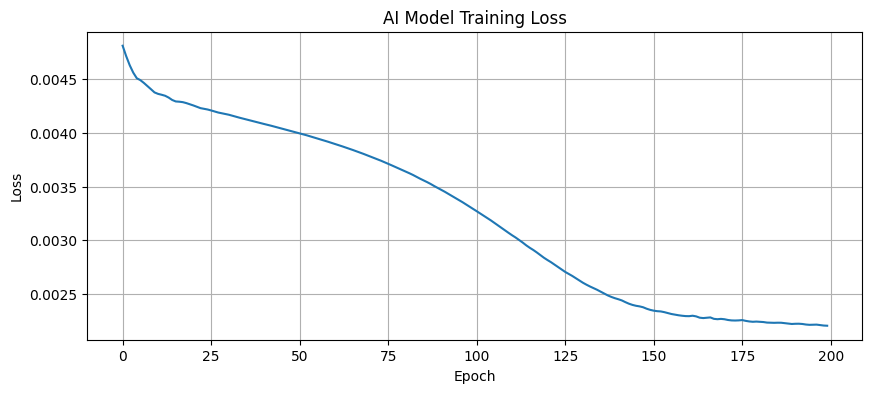

In [167]:
#training loss 
plt.figure(figsize=(10, 4))
plt.plot(train_losses)
plt.title("AI Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [168]:
#ai returns on test set 
with torch.no_grad():
    test_weights = model(x_test_tensor)
    ai_test_returns = (test_weights * y_test_tensor).sum(dim=1).numpy()

ai_test_series = pd.Series(ai_test_returns, index=x_test.index, name="AI Allocation")
ai_test_series.head()

Date
2018-01-02   -0.001234
2018-01-03    0.003257
2018-01-04    0.000707
2018-01-05    0.000322
2018-01-08    0.000375
Name: AI Allocation, dtype: float32

In [169]:
#save
weights_df = pd.DataFrame(
    test_weights.numpy(),
    index=x_test.index,
    columns=asset_cols
)

os.makedirs("../results", exist_ok=True)
weights_df.to_csv("../results/ai_weights.csv")

print("saved ../results/ai_weights.csv")
weights_df.head()

saved ../results/ai_weights.csv


,SPY,QQQ,TLT,GLD,EEM,IWM,VNQ,LQD
Date,,,,,,,,
2018-01-02,0.079391,0.064237,0.372777,0.134785,0.036554,0.050135,0.034965,0.227156
2018-01-03,0.079364,0.064203,0.372882,0.134778,0.036534,0.050101,0.034933,0.227204
2018-01-04,0.079332,0.064188,0.372965,0.134746,0.036524,0.050082,0.034924,0.227237
2018-01-05,0.079361,0.064204,0.372860,0.134780,0.036544,0.050102,0.034943,0.227206
2018-01-08,0.079370,0.064211,0.372825,0.134779,0.036554,0.050104,0.034955,0.227201


In [170]:
comparison = pd.concat(
    [ew_test_returns, mv_test_returns, ai_test_series],
    axis=1
).dropna()

comparison.head()

,Equal Weight,Mean Variance,AI Allocation
2018-01-02,0.005424,0.005424,-0.001234
2018-01-03,0.003449,0.003449,0.003257
2018-01-04,0.000100,0.000100,0.000707
2018-01-05,0.002945,0.002945,0.000322
2018-01-08,0.001444,0.001444,0.000375


In [171]:
print("shape:", comparison.shape)
print("\nmissing values:\n", comparison.isna().sum())
print("\nsummary:\n", comparison.describe())
print("\nmins:\n", comparison.min())
print("\nmaxs:\n", comparison.max())

shape: (1760, 3)

missing values:
 Equal Weight     0
Mean Variance    0
AI Allocation    0
dtype: int64

summary:
        Equal Weight  Mean Variance  AI Allocation
count   1760.000000    1760.000000    1760.000000
mean       0.000253       0.000253       0.000134
std        0.008620       0.008620       0.006419
min       -0.084666      -0.084666      -0.052384
25%       -0.003811      -0.003811      -0.003155
50%        0.000653       0.000653       0.000379
75%        0.004674       0.004674       0.003765
max        0.057044       0.057044       0.040997

mins:
 Equal Weight    -0.084666
Mean Variance   -0.084666
AI Allocation   -0.052384
dtype: float64

maxs:
 Equal Weight     0.057044
Mean Variance    0.057044
AI Allocation    0.040997
dtype: float64


In [172]:
comparison_total = (1 + comparison).cumprod()
comparison_total.head()

,Equal Weight,Mean Variance,AI Allocation
2018-01-02,1.005424,1.005424,0.998766
2018-01-03,1.008892,1.008892,1.002018
2018-01-04,1.008992,1.008992,1.002727
2018-01-05,1.011964,1.011964,1.003050
2018-01-08,1.013424,1.013424,1.003426


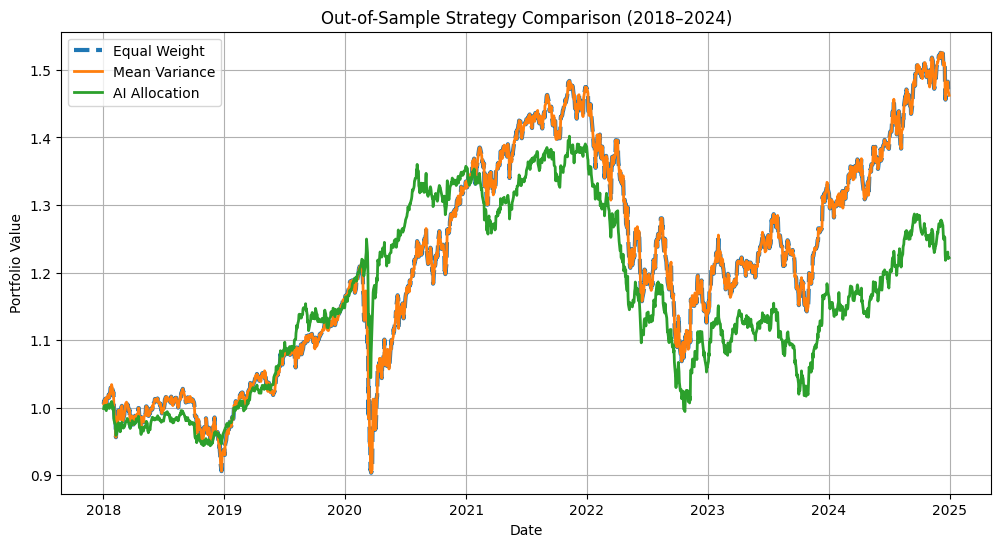

In [173]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison_total.index,
    comparison_total["Equal Weight"],
    label="Equal Weight",
    linewidth=3,
    linestyle="--"
)

plt.plot(
    comparison_total.index,
    comparison_total["Mean Variance"],
    label="Mean Variance",
    linewidth=2
)

plt.plot(
    comparison_total.index,
    comparison_total["AI Allocation"],
    label="AI Allocation",
    linewidth=2
)

plt.legend()
plt.title("Out-of-Sample Strategy Comparison (2018–2024)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()

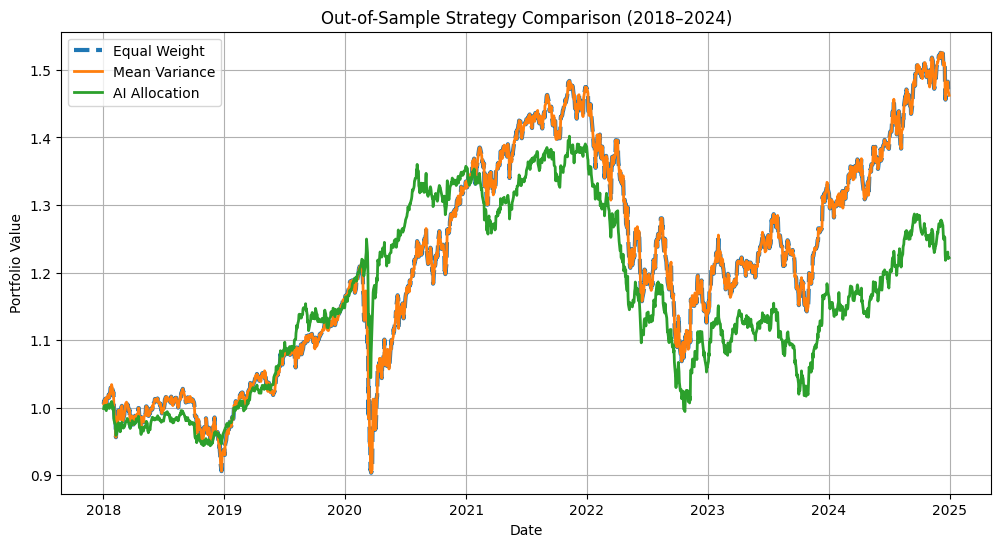

saved: results/ai_vs_benchmarks.png


In [181]:
import os

# make sure results folder exists
os.makedirs("../results", exist_ok=True)

plt.figure(figsize=(12, 6))

plt.plot(
    comparison_total.index,
    comparison_total["Equal Weight"],
    label="Equal Weight",
    linewidth=3,
    linestyle="--"
)

plt.plot(
    comparison_total.index,
    comparison_total["Mean Variance"],
    label="Mean Variance",
    linewidth=2
)

plt.plot(
    comparison_total.index,
    comparison_total["AI Allocation"],
    label="AI Allocation",
    linewidth=2
)

plt.legend()
plt.title("Out-of-Sample Strategy Comparison (2018–2024)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.grid(True)

plt.savefig(
    "../results/ai_vs_benchmarks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("saved: results/ai_vs_benchmarks.png")

In [175]:
final_metrics = pd.DataFrame({
    col: {
        "Sharpe": sharpe_ratio(comparison[col]),
        "MaxDrawdown": max_drawdown(comparison[col]),
        "Volatility": annual_volatility(comparison[col]),
        "CumulativeReturn": cumulative_return(comparison[col])
    }
    for col in comparison.columns
}).T

final_metrics

,Sharpe,MaxDrawdown,Volatility,CumulativeReturn
Equal Weight,0.466562,-0.279621,0.136846,0.462415
Mean Variance,0.466562,-0.279621,0.136846,0.462415
AI Allocation,0.332520,-0.290715,0.101905,0.221824


In [176]:
final_metrics.to_csv("../results/final_metrics.csv")
print("saved ../results/final_metrics.csv")

saved ../results/final_metrics.csv


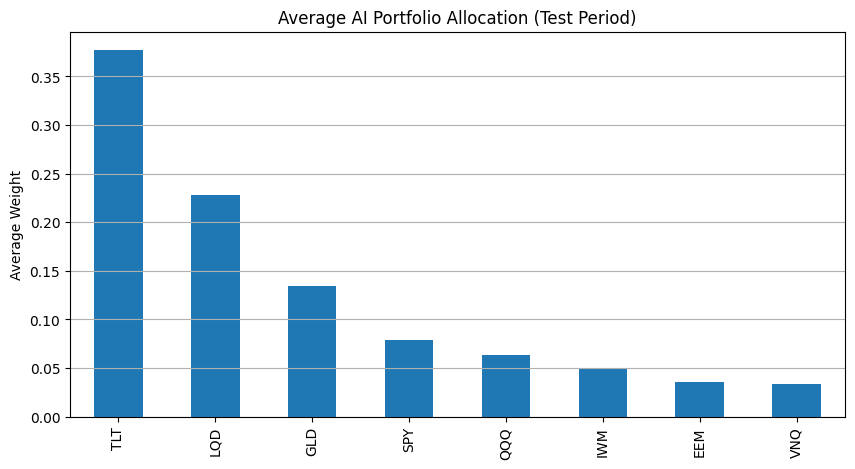

In [177]:
avg_weights = weights_df.mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
avg_weights.plot(kind="bar")
plt.title("Average AI Portfolio Allocation (Test Period)")
plt.ylabel("Average Weight")
plt.grid(True, axis="y")
plt.show()

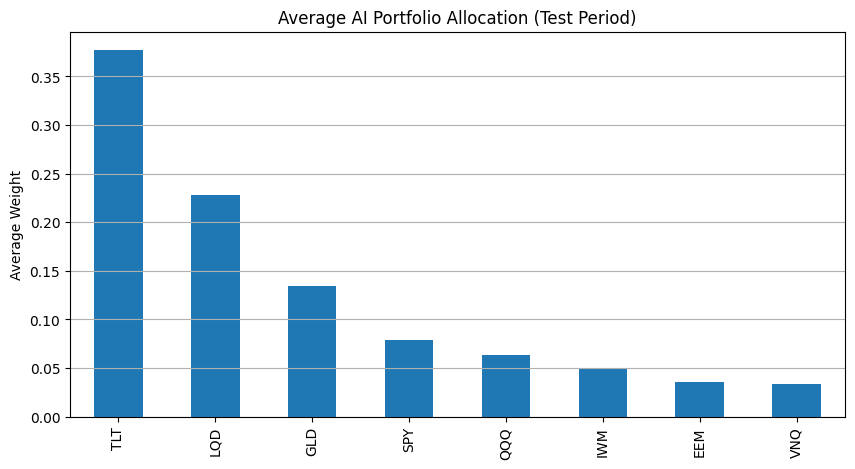

saved average_ai_allocation.png


In [178]:
plt.figure(figsize=(10, 5))
avg_weights.plot(kind="bar")
plt.title("Average AI Portfolio Allocation (Test Period)")
plt.ylabel("Average Weight")
plt.grid(True, axis="y")
plt.savefig("../results/average_ai_allocation.png", dpi=300, bbox_inches="tight")
plt.show()

print("saved average_ai_allocation.png")

In [179]:
regime_test = data.loc[X_test.index, "regime"].copy()

regime_perf = pd.DataFrame({
    "return": ai_test_series,
    "regime": regime_test
}).dropna()

regime_summary = regime_perf.groupby("regime")["return"].agg(["mean", "std", "count"])
regime_summary

,mean,std,count
regime,,,
bear,-0.005055,0.008485,201
bull,0.002490,0.004308,795
sideways,-0.000952,0.006539,764


In [180]:
regime_summary.to_csv("../results/regime_summary.csv")
print("save regime_summary.csv")

save regime_summary.csv
